# Capítulo 2: Aproximación e interpolación polinomial

> [2.1 Interpolación polinomial](#sec:interp.pol)
>
> [2.2 Aproximación por cuadrados mínimos](#sec:aprox.cuad.minimos)
>
> [2.3 Interpolación de funciones](#sec:interp.de.funciones)
>
> [2.4 Interpolación polinomial a trozos](#sec:interp.pol.a.trozos)


Antes de comenzar importemos las librerias que necesitaremos para este capítulo.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Intro <a name = "sec:intro"></a>



Consideremos la situación en que se conocen los valores de una función en algunos puntos. Esos puntos pueden provenir de mediciones experimentales y por lo tanto podrían contener errores. Se desea hallar una función *sencilla* que coincida en esos puntos, o que la gráfica pase cerca.

Consideremos el caso en que queremos calcular la integral de una función sobre la que no conocemos la *primitiva*, por ejemplo
$$
\int_0^1 e^{-x^2} \, dx.
$$
En este caso, lo que se hace, es aproximar la función por funciones sencillas que se sepan integrar,  y luego se integran esas funciones sencillas.

Para los matemáticos, las funciones más sencillas son los polinomios. Algunas razones por las que se consideran sencillas son las siguientes:

1.   **Son fáciles de representar, pues basta un número finito de coeficientes.** <br>
En python, un vector `p` de $n$ componentes representa el siguiente polinomio de grado $n-1$:
$$
p(x) = \texttt{p}_1 x^{n-1} + \texttt{p}_2 x^{n-2} + \dots + \texttt{p}_{n-1} x + \texttt{p}_n.
$$
Así, `p = [6 -3 0 1]` representa el polinomio
$$
p(x) = 6 x^3 - 3 x^2 + 0 x + 1 = 6 x^3 - 3 x^2 + 1.
$$

Para evaluar un polinomio en un cierto $x$ se utiliza la función `polyval`. Así, para graficar el polinomio dado en Python, sobre el intervalo $[-3,3]$, hacemos:

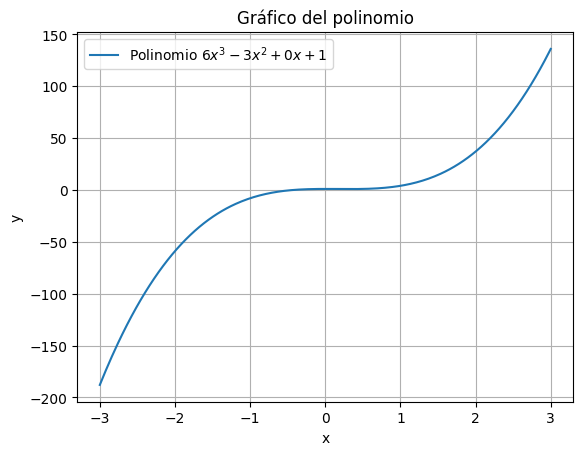

In [ ]:
# Definir el polinomio
p = np.array([6, -3, 0, 1])  # Coeficientes del polinomio

# Crear un rango de valores para x
x = np.linspace(-3, 3, 300)

# Evaluar el polinomio en los puntos de x
y = np.polyval(p, x)

# Graficar
plt.plot(x, y, label="Polinomio $6x^3 - 3x^2 + 0x + 1$")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Gráfico del polinomio")
plt.grid(True)
plt.legend()
plt.show()

Resumiendo, para Python, `p` es un vector de $4$ componentes. Cuando lo evaluamos con `polyval`, lo interpreta como un polinomio de grado $3$. Pero para que lo interprete de esa manera, hay que evaluarlo con `polyval`. Se ruega al lector entender lo que ocurre al hacer las siguientes líneas:

```
p[3]
np.polyval(p,3)
p[0]
np.polyval(p,0)
p[4]
np.polyval(p,4)
p[0.25]
np.polyval(p,0.25)
```

In [ ]:
# Utiliza este cuadro para experimentar
p[3]

2. **Son fáciles de integrar, y la integral de un polinomio es otro polinomio**
$$
\int 6 x^3 - 3 x^2 + 0 x + 1 \, dx = 6 \frac{x^4}4 -3 \frac{x^3}3 + 0 \frac{x^2}2 + 1 x + c
= \frac64 x^4 -\frac33 x^3 + \frac02 x^2 + 1 x + c
$$
para cualquier constante $c$.
En general
$$
\int p_1 x^{n-1}  + p_2 x^{n-2} + \dots + p_{n-1} x + p_n
\, dx
 =  \frac{p_1}n x^{n}  + \frac{p_2}{n-1} x^{n-1} + \dots + \frac{p_{n-1}}2 x^2 + p_n x + C.
$$<br>

3.  **Son fáciles de derivar, y la derivada de un polinomio es otro polinomio**
$$
\frac{d}{dx} \left(6 x^3 - 3 x^2 + 0 x + 1\right)  = 6 \cdot 3 \, x^2 -3\cdot 2\, x + 0 ,
$$
En general
$$
\frac{d}{dx} \left(p_1 x^{n-1}  + p_2 x^{n-2} + \dots + p_{n-1} x + p_n \right)
 =  (n-1)p_1 x^{n-2}  + (n-2)p_2 x^{n-3} + \dots + 3p_{n-3} x^2 + 2p_{n-2} x + p_{n-1}.
$$

><font size = "4"> ⚙️ **Desafío** </font>
>
> ¿Se anima a escribir una función que dado como entrada un vector que representa a un polinomio devuelva el vector que representa al polinomio  integrado?
¿Y otra que devuelva el polinomio derivado?

In [ ]:
# Escriba aquí la resolución del Desafío

# 2.1 Interpolación polinomial <a name = "sec:interp.pol"></a>



Dados dos puntos en el plano, pasa por ellos una única recta.

Si los dos puntos tienen diferente abscisa, entonces hay una única recta de ecuación
$$
y = ax+b
$$
cuya gráfica pasa por los puntos.

Si tengo tres puntos con diferente abscisa, por ejemplo
$$
(1,8) \qquad (-1,9) \qquad (2,15),
$$
veremos que pasa por ellos una única parábola de ecuación
$$
y = a x^2 + b x + c.
$$
Veamos cómo se calcula dicha parábola. Para que la misma pase por los puntos debe cumplir

\begin{align*}
&(1,8) \text{ está sobre la parábola } & &\iff & & 8 = a 1^2 + b 1 + c \\
&(-1,9) \text{ está sobre la parábola }& & \iff & & 9 = a (-1)^2 + b (-1) + c \\
&(2,15) \text{ está sobre la parábola } & &\iff & & 15 = a 2^2 + b 2 + c .
\end{align*}

Nos queda entonces un sistema de 3 ecuaciones con 3 incógnitas (las incógnitas son $a$, $b$, $c$)

\begin{align*}
1^2 a + 1 b + c &= 8 \\
(-1)^2 a + (-1) b + c &= 9\\
2^2 a + 2 b + c &=15 .
\end{align*}

En forma matricial, el sistema se escribe como

$$
\begin{bmatrix}
1^2 & 1 & 1 \\
(-1)^2 & (-1) & 1 \\
2^2 & 2 & 1
\end{bmatrix}
\begin{bmatrix}
a \\ b \\ c
\end{bmatrix}
=
\begin{bmatrix}
8 \\ 9 \\ 15
\end{bmatrix}
$$

Notamos que el lado derecho de la ecuación es el vector de ordenadas de los puntos (coordenadas $y$) y las columnas de la matriz son potencias de las abscisas de los puntos (coordenadas $x$). Para resolverlo en Python hacemos así:

In [ ]:
# Definir los datos
X = np.array([1, -1, 2])
Y = np.array([8, 9, 15])

# Construir la matriz directamente
matriz = np.array([X**2, X, np.ones_like(X)]).T

# Resolver el sistema de ecuaciones por mínimos cuadrados
p = np.linalg.solve(matriz, Y)

# Mostrar resultados
print("Matriz:")
print(matriz)
print("Coeficientes del polinomio:")
print(p)

Matriz:
[[ 1  1  1]
 [ 1 -1  1]
 [ 4  2  1]]
Coeficientes del polinomio:
[ 2.5 -0.5  6. ]



Así, $a=2.5$, $b = -0.5$ y $c = 6$.<BR>
Para graficar el polinomio en el intervalo $[-2,3]$ y los puntos dados hacemos lo siguiente:

In [ ]:
# Crear un rango de valores
xx = np.linspace(-2, 3, 200)

# Evaluar el polinomio ajustado en los puntos
yy = np.polyval(p, xx)

# Graficar
plt.plot(xx, yy, label="Ajuste polinómico")
plt.plot(X, Y, '*', label="Datos originales")  # Graficar los puntos de los datos
plt.xlabel("x")
plt.ylabel("y")
plt.title("Ajuste Polinómico")
plt.legend()
plt.grid(True)
plt.show()

Ahora nos preguntamos qué ocurre cuando tenemos $n$ puntos. La respuesta está en el siguiente teorema.

> <font size = "5"> Teorema 2.1 </font> <a name = "teo:existencia.pol.interp"></a>
>
>Dados $n$ puntos
$$
(x_1,y_1) \quad (x_2,y_2) \quad \dots \quad (x_n,y_n)
$$
con abscisas todas distintas,
existe un único polinomio $p$ de grado $n-1$ cuya gráfica pasa por los puntos, es decir
$$
p(x_i) = y_i , \quad i=1,2,\dots,n.
$$


Para demostrar este teorema recordamos que el Teorema Fundamental del álgebra dice:

>*''Un polinomio de grado $n-1$ tiene exactamente $n-1$ ceros en el conjunto de los números complejos.''*

Sin entrar en detalles sobre lo que son los números complejos, deducimos de ese enunciado que

>*Un polinomio de grado $n-1$ tiene a lo sumo $n-1$ ceros reales.*


Esto implica a su vez que:

>*Si* $p(x) = p_1 x^{n-1} + p_2 x^{n-2} + \dots + p_{n-1} x + p_n$ *cumple*
$$
p(x_i) = 0, \qquad i=1,2,\dots,n,
$$
*con todos los $x_i$ distintos, es decir, tiene $n$ ceros, entonces*
$$
p_1 = p_2 = \dots = p_{n-1} = p_n = 0.
$$

Ahora sí, estamos en condiciones de demostrar el teorema.

> <font size = "4"> Demostración del [Teorema 2.1](#teo:existencia.pol.interp) </font>
>
>Queremos hallar el polinomio, así  que proponemos
$$
p(x) = p_1 x^{n-1} + p_2 x^{n-2} + \dots + p_{n-1} x + p_n.
$$
El mismo debe cumplir las siguiente $n$ ecuaciones
\begin{align*}
p(x_1) &= y_1 \\
p(x_2) &= y_2 \\
& \vdots \\
p(x_n) &= y_n.
\end{align*}<br>
Es decir<br><br>
\begin{align*}
p_1 x_1^{n-1} + p_2 x_1^{n-2} + \dots + p_{n-1} x_1 + p_n &= y_1 \\
p_1 x_2^{n-1} + p_2 x_2^{n-2} + \dots + p_{n-1} x_2 + p_n &= y_2 \\
& \vdots \\
p_1 x_n^{n-1} + p_2 x_n^{n-2} + \dots + p_{n-1} x_n + p_n &= y_n.
\end{align*}<br>
Recordando que las abscisas $x_1, x_2, \dots, x_n$ son conocidas y las ordenadas $y_1, y_2, \dots, y_n$ también, las incógnitas son los coeficientes $p_1, p_2, \dots, p_n$ del polinomio. Para encontrarlos debemos resolver ese sistema de ecuaciones que en forma matricial se escribe<a name = "eq:2.1"></a> <br>
$$
\begin{bmatrix}
x_1^{n-1} & x_1^{n-2} & \dots &  x_1  & 1  \\
x_2^{n-1} & x_2^{n-2} & \dots &  x_2  & 1  \\
\vdots & \vdots & & \vdots & \vdots \\
x_n^{n-1} & x_n^{n-2} & \dots &  x_n  & 1  \\
\end{bmatrix}
\begin{bmatrix}
p_1 \\ p_2 \\ \vdots \\ p_{n-1} \\ p_n
\end{bmatrix}
=
\begin{bmatrix}
y_1 \\ y_2 \\ \vdots \\ y_{n-1} \\ y_n
\end{bmatrix}.\qquad (2.1)
$$
Observamos nuevamente que el lado derecho del sistema de ecuaciones es el vector de ordenadas de los puntos (coordenadas $y$) y las columnas de la matriz son potencias de las abscisas de los puntos (coordenadas $x$). Esta matriz se conoce como *matriz de Vandermonde* correspondiente a $x_1, x_2, \dots, x_n$. <br>
Este sistema de ecuaciones tiene solución única si y sólo si el problema homogéneo tiene como única solución a la trivial.
Plantear el sistema homogéneo<br><br>
$$
\begin{bmatrix}
x_1^{n-1} & x_1^{n-2} & \dots &  x_1  & 1  \\
x_2^{n-1} & x_2^{n-2} & \dots &  x_2  & 1  \\
\vdots & \vdots & & \vdots & \vdots \\
x_n^{n-1} & x_n^{n-2} & \dots &  x_n  & 1  \\
\end{bmatrix}
\begin{bmatrix}
p_1 \\ p_2 \\ \vdots \\ p_{n-1} \\ p_n
\end{bmatrix}
=
\begin{bmatrix}
0 \\ 0 \\ \vdots \\ 0
\end{bmatrix}
$$<br>
equivale a buscar el polinomio que satisface $p(x_i) = 0$, $i=1,2,\dots,n$.
Por lo que hemos dicho antes de comenzar la demostración, esto implica que
$p_1 = p_2 = \dots = p_{n-1} = p_n = 0$, es decir, la única solución es la trivial.<br>
Por lo tanto, el sistema [(2.1)](#eq:2.1) tiene solución única, o lo que es lo mismo, existe un único polinomio cuya gráfica pasa por los $n$ puntos dados.

> ### Observación
> No es difícil probar que las matrices de Vandermonde $V$ satisfacen que $$\det(V)=\prod _{0\leq i<j\leq m}(x_j-x_i).$$
Lo cual es claramente no nulo si y sólo si todos $x_i$ son distintos (lo cual es siempre nuestro caso), resultando en que $V$ es invertible.

En Python, para hallar el polinomio de grado $n-1$ que pasa por $n$ puntos, se utiliza la función `polyfit`.

Por ejemplo, para hallar el polinomio de grado 4 cuya gráfica pasa por

$$
(1,2)\quad (2,-1) \quad (4.5,3) \quad (5.5,0) \quad (10,3.3)
$$

hacemos lo siguiente

In [ ]:
# Definir los datos
X = np.array([1, 2, 4.5, 5.5, 10])  # Numpy no necesita la transposición
Y = np.array([2, -1, 3, 0, 3.3])

# Ajuste polinómico de grado 4
p = np.polyfit(X, Y, 4)

print("Coeficientes del polinomio:", p)

Ahora grafiquemos el polinomio en el intervalo $[0,11]$ y veamos si realmente *interpola* los datos.

In [ ]:
# Crear un rango de valores para xx
xx = np.linspace(0, 11, 200)

# Evaluar el polinomio ajustado en los puntos de xx
yy = np.polyval(p, xx)

# Graficar
plt.plot(xx, yy, label="Ajuste polinómico")
plt.plot(X, Y, '*', label="Datos originales")  # Graficar los datos como puntos
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title("Ajuste Polinómico")
plt.grid(True)
plt.show()

---
<font size="5">Pongámonos a prueba!!! 💪🏻</font> <br>

Intentá hallar la solución a los siguientes problemas con los conocimientos adquiridos en esta sección.
Recordá que si bien estás buscando un resultado en particular, herramientas como gráficas u otros cálculos auxiliares pueden ser de mucha ayuda para llegar a este.
Podés resolver utilizando celdas de código en este mismo colab, o corriendo python de manera local.

### Ejercicio de interpolación polinomial 1


Consideremos los siguientes puntos

$$(1, 1.54), (2, 1.5), (3, 1.42), (5, 0.66).$$

1. Calcular el polinomio $p(x)$ de grado $3$ cuya gráfica pasa por esos puntos.

2. Graficar los puntos y el polinomio en el intervalo $[0, 6]$.

3. Calcular $p(4)$, $p'(4)$ y $\int^4_1{p(x)}\,dx$.

In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

### Ejercicio de interpolación polinomial 2 <a name = "ej:mosquitos"></a>


Un biólogo realiza un experimento de reproducción de mosquitos y toma las siguientes mediciones

|Semana|Cantidad|
|-|-|
|0|432|
|1|599|
|2|1012|
|3|1909|
|4|2977|
|5|4190|
|6|5961|

1. Determinar el polinomio $p_6$ de grado igual que 6 que interpola los datos de la tabla.

2. Graficar la curva interpolada junto a los datos experimentales.


In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

---

# 2.2. Aproximación por cuadrados mínimos <a name = "sec:aprox.cuad.minimos"></a>

En la sección anterior vimos cómo calcular un **polinomio interpolador** de una lista de puntos.
Es decir, buscábamos el polinomio cuya gráfica pasa exactamente por todos los puntos dados. Volveremos a esto en la sección siguiente, lo que será útil para obtener fórmulas de integración numérica en el capítulo próximo.

Ahora nos enfocaremos en el cálculo de un polinomio de grado bajo que pase *cerca* de una lista dada de puntos. Algo similar a los que muestra la siguiente gráfica:

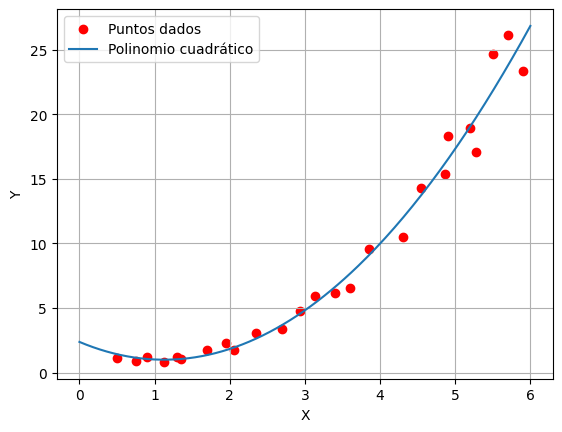

Consideremos el caso en que tenemos $n$ puntos<br><br>
$$
(x_1,y_1)\quad (x_2,y_2)\quad \dots \quad(x_n,y_n)
$$<br>
con $n$ grande, como en la gráfica, y buscamos un polinomio de grado menor o igual a 2, cuya gráfica pase lo más cerca posible de esos puntos.
Debemos definir en qué sentido el polinomio pasa cerca de los puntos.
La manera más usual es lo que se conoce como la aproximación por cuadrados mínimos, que consiste en lo siguiente.
Queremos hallar el polinomio $p(x)$ que minimice la suma de la distancia entre $p(x_i)$ y $y_i$ al cuadrado, es decir, que minimice la siguiente expresión<br><br>
$$
\big(p(x_1) - y_1\big)^2 + \big(p(x_2) - y_2\big)^2 + \dots + \big(p(x_n) - y_n\big)^2
= \sum_{i=1}^n \big(p(x_i) - y_i\big)^2.
$$<br>
Geométricamente, estamos mirando la distancia *vertical* entre el punto *dato* $(x_i,y_i)$ y el punto de la gráfica con la misma abscisa $(x_i,p(x_i))$. Lo que se quiere minimizar es la suma de esas distancias al cuadrado. En notación más compacta, queremos minimizar la norma euclídea o magnitud de este vector<br><br>
$$
\begin{bmatrix}
p(x_1) \\ p(x_2) \\ \vdots \\ p(x_n)
\end{bmatrix}
-
\begin{bmatrix}
y_1 \\ y_2 \\ \vdots \\ y_n
\end{bmatrix}
=
\begin{bmatrix}
p_1 x_1^2 + p_2 x_1 + p_3  \\ p_1 x_2^2 + p_2 x_2 + p_3  \\ \vdots
\\ p_1 x_n^2 + p_2 x_n + p_3  
\end{bmatrix}
-
\begin{bmatrix}
y_1 \\ y_2 \\ \vdots \\ y_n
\end{bmatrix}
$$<br>
Observamos que<br><br>
$$
\begin{bmatrix}
p_1 x_1^2 + p_2 x_1 + p_3  \\ p_1 x_2^2 + p_2 x_2 + p_3  \\ \vdots
\\ p_1 x_n^2 + p_2 x_n + p_3  
\end{bmatrix}
=
\underbrace{
\begin{bmatrix}
 x_1^2 & x_1 & 1   \\
 x_2^2 & x_2 & 1   \\
 \vdots  \\
 x_n^2 & x_n & 1  
\end{bmatrix}}_{M}
\underbrace{
\begin{bmatrix}
p_1 \\ p_2 \\ p_3
\end{bmatrix}}_{\boldsymbol{p}}
$$<br>
y planteamos el siguiente problema.<br>
Hallar el vector $\boldsymbol{p}$ que minimice la norma de $M \boldsymbol{p} - \boldsymbol{y}$, es decir, que minimice<br><br>
$$
\| M \boldsymbol{p} - \boldsymbol{y} \| = \left( \sum_{i=1}^n \big[(M\boldsymbol{p})_i - y_i]^2\right)^{1/2}
$$<br>
Para resolver este problema, recordemos que $M \boldsymbol{p}$ es una combinación lineal de las columnas de $M$<br><br>
$$
M \boldsymbol{p} = p_1 \text{col}_1(M) + p_2 \text{col}_2(M) + p_3 \text{col}_3(M),
$$<br>
y por lo tanto, el problema consiste en encontrar el elemento del *espacio columna* de $M$ que está lo más cerca posible de $\boldsymbol{y}$.<br>
Recordando un poco de geometría, vemos que $M\boldsymbol{p}$ es el elemento de dicho espacio más cercano a $\boldsymbol{y}$ si y sólo si el *error* $\boldsymbol{y} - M \boldsymbol{p}$  es perpendicular al espacio generado por las columnas de $M$. Es decir, si $\boldsymbol{y}-M\boldsymbol{p}$ es perpendicular a cada columna de $M$. Más precisamente, si se cumple que<br><br>
\begin{align*}
\text{col}_1(M) \cdot (\boldsymbol{y} - M \boldsymbol{p}) &= 0 \\
\text{col}_2(M) \cdot (\boldsymbol{y} - M \boldsymbol{p}) &= 0 \\
\text{col}_3(M) \cdot (\boldsymbol{y} - M \boldsymbol{p}) &= 0 .
\end{align*}<br>
Recordando que si $u$, $v$ son vectores columna, entonces $u \cdot v = u^T v$ resulta que $M\boldsymbol{p}$ debe cumplir<br><br>
\begin{align*}
\text{col}_1(M)^T (\boldsymbol{y} - M \boldsymbol{p}) &= 0 \\
\text{col}_2(M)^T (\boldsymbol{y} - M \boldsymbol{p}) &= 0 \\
\text{col}_3(M)^T (\boldsymbol{y} - M \boldsymbol{p}) &= 0 .
\end{align*}<br>
En notación mós compacta<br><br>
$$
\begin{bmatrix}
\text{col}_1(M)^T \\
\text{col}_2(M)^T \\
\text{col}_3(M)^T
\end{bmatrix}
(\boldsymbol{y} - M \boldsymbol{p})
= \begin{bmatrix} 0\\0\\0 \end{bmatrix}
\qquad\iff\qquad
M^T (\boldsymbol{y} - M \boldsymbol{p})
= \begin{bmatrix} 0\\0\\0 \end{bmatrix}
$$<br>
A su vez, esta última expresión, equivale a<br><br>
$$
M^T M \boldsymbol{p} = M^T \boldsymbol{y}.
$$<br>
Es decir, el vector $\boldsymbol{p}$ (de tres componentes) debe ser la solución al sistema de ecuaciones<br><br>
$$
\big( M^T M\big) \boldsymbol{p} = M^T \boldsymbol{y}.
$$

En Python, si `X`, `Y` son vectores que tienen las abscisas y las ordenadas de los puntos, el cálculo del polinomio $p$ se haría de la siguiente manera

In [ ]:
# Datos (puntos dados)
X = np.array([0.5,0.75,0.9,1.12,
              1.3,1.35,1.7,1.95,
              2.05,2.35,2.7,2.93,
              3.14,3.4,3.6,3.85,
              4.3,4.55,4.87,4.9,
              5.2,5.28,5.5,5.7,5.9])
Y = np.array([1.13, 0.87, 1.20, 0.83, 1.24,
              1.09, 1.75, 2.26, 1.73, 3.1,
              3.38, 4.8, 5.93, 6.17, 6.55,
              9.56, 10.46, 14.28, 15.34, 18.29,
              18.89, 17.09, 24.63, 26.10, 23.3])

# Paso 1: armado de la matriz M
M = np.array([X**2, X, np.ones_like(X)]).T

# Paso 2: armamos la matriz del sistema
A = M.T @ M

# Paso 3: armamos el lado derecho del sistema
b = M.T @ Y

# Paso 4: hallamos los coeficientes del polinomio que aproximan en el sentido de mínimos cuadrados
p = np.linalg.solve(A, b)

# Generamos el intervalo para xx, por ejemplo, [0, 6]
xx = np.linspace(0, 6, 200)

# Evaluamos el polinomio en los puntos xx
yy = np.polyval(p, xx)

# Graficamos los puntos originales y la curva ajustada
plt.scatter(X, Y, color='red', label="Puntos dados")  # Puntos originales
plt.plot(xx, yy, label="Polinomio ajustado")  # Curva ajustada
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Ajuste polinómico por mínimos cuadrados")
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'np' is not defined

Los Pasos $1$ al $4$ del procedimiento anterior pueden resumirse haciendo uso del comando `polyfit`, i.e.

>`p = np.polyfit(X,Y,2)`


Sin embargo es importante entender cómo se resuelve un sistema en el sentido de mínimos cuadrados, pues hay ocasiones en que se requiere aproximar datos que provengan de funciones no polinómicas, como ser

$$p(x) = a 3^x + b 2^x + c.$$

Aunque en este caso no podremos usar el comando `np.polyfit` (¿por qué?), podemos repitir los pasos anteriores pero sustituyendo la matriz $M$ por una de la forma

> `M = np.array([ 3**X,  2**X,  np.ones_like(X)]).T`

y aún así obtener el resultado deseado.

En las ejercicios veremos casos como este y algunos aún más complejos.

---
<font size="5">Pongámonos a prueba!!! 💪🏻</font> <br>

Intentá hallar la solución a los siguientes problemas con los conocimientos adquiridos en esta sección.
Recordá que si bien estás buscando un resultado en particular, herramientas como gráficas u otros cálculos auxiliares pueden ser de mucha ayuda para llegar a este.
Podés resolver utilizando celdas de código en este mismo Colab, o corriendo Python de manera local.

### Problema de mínimos cuadrados 1

Continuemos con la interpolación de los datos de mosquitos del [Ejercicio de interpolación polinomial 2](#ej:mosquitos).

1. Determinar la función lineal $p_1$ que mejor aproxima en el sentido de cuadrados mínimos los datos dados (modelo lineal).

2. Determinar el polinomio $p_2$ de grado $\le 2$ que mejor aproxima en el sentido de cuadrados mínimos los datos dados (modelo cuadrático).

3. Graficar los datos y la evolución de los $3$ modelos calculados durante las $6$ semanas. Determinar el error cuadrático en cada caso. ¿cuál de los modelos le parece que es más apropiado y por qué?

4. Predecir cuál será la cantidad de mosquitos al cabo de $10$ semanas según los diferentes modelos propuestos.
¿Sigue pensando que el modelo más apropiado es el que eligió en el item anterior?

5. Si se sabe que la medición a las $10$ semanas es de $14900$ mosquitos, calcule el error relativo de cada una de sus predicciones y verifique si el modelo que consideró más apropiado es el que da la mejor predicción.

In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

### Problema de mínimos cuadrados 2

Se calculó la energía térmica total E de una barra y los datos se reportan en el archivo `datos_energia.txt` (ver [Datos para el TP2](https://servicios.unl.edu.ar/aulavirtual/fiq/mod/folder/view.php?id=13093) en el aula virtual).

1. Grafique la energía térmica total de la barra $E(t_i)$ en cada uno de los instantes de tiempo $t_i$ dados.

2. Calcule el polinomio $p(t)$ de grado 8 que aproxima los puntos $(t_i
, E(t_i))$ en el sentido de cuadrados mínimos.<br>
 Grafique dicho polinomio junto a los datos y calcule el error cuadrático correspondiente al ajuste.

3. Utilice el ajuste realizado en el item anterior para calcular la máxima tasa de cambio instantánea de la energía total en la barra y diga en qué momento ocurre con 5 cifras significativas de precisión.

In [ ]:
 # Usa esta celda sólo en caso de no disponer del Spyder en este momento

### Problema de mínimos cuadrados 3

Considere las mediciones dadas en el archivo `datos_poblacion.txt` (ver [Datos para el TP2](https://servicios.unl.edu.ar/aulavirtual/fiq/mod/folder/view.php?id=13093) en el aula virtual), que corresponden a la evolución de un cierta población en el intervalo $[0, 15]$.

1. ¿Cuál es el grado polinomial más pequeño para el cuál el ajuste por cuadrados mínimos le parece razonable?

2. Según su modelo, ¿cuál es la tasa de crecimiento más grande alcanzada y en qué momento ocurre?

In [ ]:
 # Usa esta celda sólo en caso de no disponer del Spyder en este momento

### Problema de mínimos cuadrados 4

En el archivo `datos_censos_argentina.txt`  (ver [Datos para el TP2](https://servicios.unl.edu.ar/aulavirtual/fiq/mod/folder/view.php?id=13093) en el aula virtual) se encuentra la población total de Argentina para diferentes años según el INDEC.

1. Determinar los ajustes lineal y cuadrático en el sentido de mínimos cuadrados para los datos y graficar.

2. Calcular el error cuadrático de ambos ajustes. ¿Alguno de los ajustes le parece razonable? ¿Por qué?

3. Determinar la población predecida para este año con ambos ajustes. Buscar la población estimada de hoy en la página de INDEC y calcular el error relativo porcentual de ambas predicciones.

4. Teniendo en cuenta los resultados del item anterior, decida si en efecto alguno de los dos modelos le parece razonable. En caso afirmativo, utilícelo para determinar cuántos años faltan para que lleguemos a ser 50 millones de argentinos.

In [ ]:
 # Usa esta celda sólo en caso de no disponer del Spyder en este momento

### Problema de mínimos cuadrados 5

Considerar los datos $(x_i, y_i)$, para $i = 1, . . . , 21$ dados en el archivo `datos_erf.txt`.  (ver [Datos para el TP2](https://servicios.unl.edu.ar/aulavirtual/fiq/mod/folder/view.php?id=13093) en el aula virtual)

1. Considere el polinomio $p_3$ de grado ≤ 3 que mejor aproxima en el sentido de cuadrados mínimos los datos dados. Calcule el error cuadrático y utilice el modelo para predecir el valor en $x = 11$.

2. Considere el polinomio $p_5$ de grado $\le 5$ que mejor aproxima en el sentido de cuadrados mínimos los datos dados. Calcule el error cuadrático y utilice el modelo para predecir el valor en $x = 11$.

3. Determine la función de la forma $$g(x) = c_1 x e^{-x^2} + c_2 \arctan(x) + c_3 \frac{x}{x^2+1}$$ que mejor aproxima en el sentido de cuadrados mínimos los datos dados. Calcule el error cuadrático y utilice el modelo para predecir el valor en $x = 11$.

4. ¿Cuál de los $3$ modelos le parece más apropiado y por qué?

5. Considere la función $g$ determinada en el item (c). Halle el valor de $x$ (con $6$ cifras significativas correcta) tal que $g(x) = 0.26$.
> 💡 **Sugerencia:** No aproxime los valores de $c_1$, $c_2$ y $c_3$ calculados en el ítem 3. Use dichos valores con toda la precisión calculada.

6. Suponga que en el ítem 3 sólo puede usar $2$ de las $3$ funciones que componen el modelo. ¿Cuál de ellas descartaría y por qué?

In [ ]:
 # Usa esta celda sólo en caso de no disponer del Spyder en este momento

---

# 2.3 Interpolación de funciones <a name = "sec:interp.de.funciones"></a>

Volvemos ahora a la idea del polinomio interpolador, es decir, el polinomio cuya gráfica pasa exactamente por una lista de puntos.
Pero consideramos ahora que esos puntos coinciden con puntos de la gráfica $y=f(x)$ de una función $f$ dada.

Hagamos un poco de matemática experimental. Para ello, a continuación incluimos una función de Python `pruebapolyfit` que dada una función $f$, un intervalo $[a,b]$ y un número $n$ de puntos calcula el polinomio interpolante en $n$ puntos **equidistantes**. La idea es tratar de *medir el error* entre la función y el polinomio hallado.

In [ ]:
def pruebapolyfit(f, a, b, n, graf):
    """
    Interpola la función f en n puntos equiespaciados en el intervalo [a, b].

    Argumentos:
    f -- función a interpolar
    a, b -- extremos del intervalo
    n -- número de puntos equiespaciados
    graf -- 1 si deseamos graficar, 0 si no lo deseamos

    Retorna:
    p -- coeficientes del polinomio interpolante en formato numpy
    maximo_error -- máximo error entre la función y el polinomio
    """
    # Puntos equiespaciados en [a, b]
    X = np.linspace(a, b, n)
    # Evaluación de f en los puntos
    Y = f(X)
    # Obtención del polinomio interpolante
    p = np.polyfit(X, Y, n - 1)

    # Puntos adicionales para graficar
    xx = np.linspace(a, b, 200)
    # Evaluación de la función y del polinomio
    fxx = f(xx)
    pxx = np.polyval(p, xx)
    # Cálculo del error absoluto
    error = np.abs(fxx - pxx)
    maximo_error = np.max(error)

    if graf == 1:
      # Gráfico 1: Función original y polinomio interpolante
      plt.figure(1)
      plt.plot(xx, fxx, label="Función original", linewidth=2)
      plt.plot(xx, pxx, label="Polinomio interpolante", linewidth=2)
      plt.scatter(X, Y, color='red', label="Puntos de interpolación")
      plt.legend()
      plt.xlabel("x")
      plt.ylabel("y")
      plt.title("Interpolación polinómica")
      plt.grid(True)
      plt.show()

      # Gráfico 2: Error absoluto
      plt.figure(2)
      plt.plot(xx, error, label="Error absoluto", linewidth=2)
      plt.xlabel("x")
      plt.ylabel("Error")
      plt.title("Error de interpolación")
      plt.grid

    return p, maximo_error

### **Ejemplo 2.2.** <a name = "ejemplo:sinx"></a>

Veamos qué ocurre cuando interpolamos la función $f(x) = \sin(x)$ sobre el intervalo $[0,7]$. Puede utilizar el código aquí mismo para realizar las pruebas usted mismo.

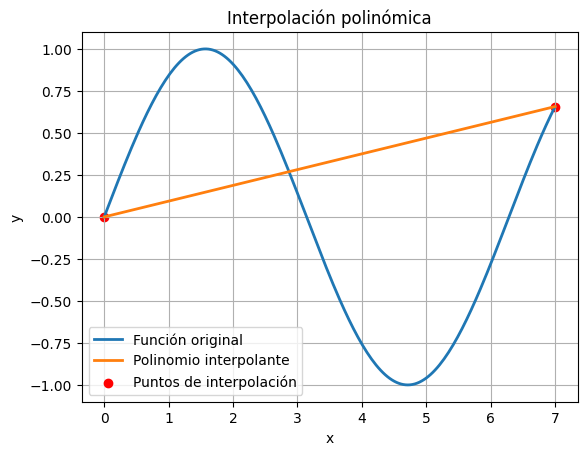

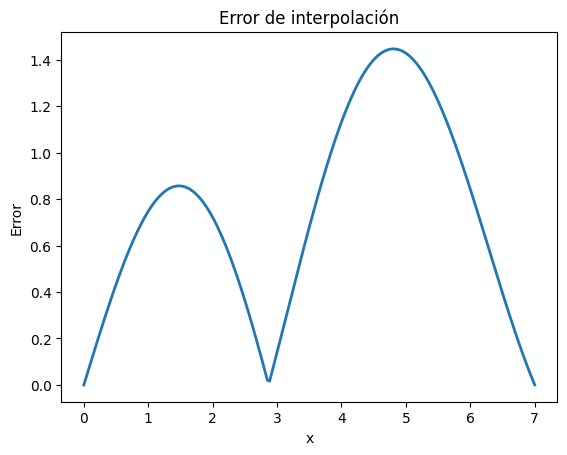

In [ ]:
# Definimos la función a interpolar
f = lambda x: np.sin(x)
# Intervalo y
a, b = 0, 7
# Número de puntos
n = 2
# Activamos la opción para que grafique
graf = 1
# Llamada a la función
p,max_error=pruebapolyfit(f,a,b,n,graf)

Ahora hagamos diferentes pruebas a la medida que incrementamos la cantidad de puntos, es decir $n$, y veamos cómo se comporta el error. Variemos $n$ entre 2 y 10:

In [ ]:
# Número de puntos
n = 2
# Desactivamos la opción para que grafique
graf = 0
# Llamada a la función
p, max_error = pruebapolyfit(f,a,b,n,graf)

print("Máximo error para n =",n, "es", max_error)

Máximo error para n = 2 es 1.4466095683250675


Asegurese de obtener los siguientes resultados:

In [ ]:
# @title Tabla errores de interpolación $f(x)=\sin(x)$ {"vertical-output":true}
import numpy as np
import pandas as pd

max_error_list = []

for n in range(2, 11):
  _, max_error = pruebapolyfit(lambda x: np.sin(x), 0, 7, n, 0)
  max_error_list.append(max_error)

# Crear un DataFrame de pandas
tabla = pd.DataFrame({'n': range(2, 11), 'Máximo error': max_error_list})

# Mostrar la tabla
display(tabla.style.format({"Máximo error": "{:.8e}"}).hide(axis="index"))

n,Máximo error
2,1.44660957e+00
3,1.33191877e+00
4,5.72191304e-01
5,3.11311304e-01
6,8.74212989e-02
7,4.02631509e-02
8,7.86685727e-03
9,3.16013241e-03
10,4.66733914e-04


Vemos en este ejemplo que el error **tiende a cero** a medida que aumentamos el número $n$ de puntos

### **Ejemplo 2.3.** <a name = "ejemplo:e^-x^2"></a>

Consideremos  ahora $f = e^{-x^2}$ y veamos qué ocurre cuando realizamos el mismo experimento en el intervalo $[-1,3]$ con $n$ variando nuevamente entre $2$ y $10$:

In [ ]:
# Definimos la función a interpolar
f = lambda x: np.exp(-x**2)
# Intervalo y
a, b = -1, 3
# Número de puntos
n = 20
# Desctivamos la opción para que grafique
graf = 0
# Llamada a la función
p, max_error = pruebapolyfit(f,a,b,n,graf)

print("Máximo error para n =",n, "es", max_error)

Máximo error para n = 20 es 1.3104506380908967e-05


Nuevamente vriando $n$ entre $2$ y $10$, asegurese de obtener los siguientes resultados

In [ ]:
# @title Tabla errores de interpolación $f(x)=e^{-x^2}$ {"vertical-output":true}
import numpy as np
import pandas as pd

max_error_list = []

for n in range(2, 11):
  _, max_error = pruebapolyfit(lambda x: np.exp(-x**2), -1, 3, n, 0)
  max_error_list.append(max_error)

# Crear un DataFrame de pandas
tabla = pd.DataFrame({'n': range(2, 11), 'Máximo error': max_error_list})

# Mostrar la tabla
display(tabla.style.format({"Máximo error": "{:.8e}"}).hide(axis="index"))

n,Máximo error
2,7.26174300e-01
3,5.86126964e-01
4,2.06981565e-01
5,2.36921234e-01
6,8.43537280e-02
7,6.56210558e-02
8,5.20115150e-02
9,2.36662973e-02
10,1.94718910e-02


Aquí también parece ser que el error **tiende a cero**, aunque da la impresión de que esto ocurre más *lentamente* que en el ejemplo anterior.

Veamos un último ejemplo.

### **Ejemplo 2.4.** <a name = "ejemplo:1/1+x^2"></a>


Consideremos la función $f(x) = \frac{1}{1+x^2}$ sobre el intervalo $[-5,5]$.

In [ ]:
# Definimos la función a interpolar
f = lambda x: 1/(1+x**2)
# Intervalo y
a, b = -5, 5
# Número de puntos
n = 30
# Desctivamos la opción para que grafique
graf = 0
# Llamada a la función
p, max_error = pruebapolyfit(f,a,b,n,graf)

print("Máximo error para n =",n, "es", max_error)

Máximo error para n = 30 es 323.7698844705722


Varian $n$ entre 2 y 10 nuevamente deberíamos obtener los siguiente resultados:

In [ ]:
# @title Tabla errores de interpolación $f(x) = \frac{1}{1+x^2}$ {"vertical-output":true,"display-mode":"form"}
import numpy as np
import pandas as pd

max_error_list = []

for n in range(2, 11):
  _, max_error = pruebapolyfit(lambda x: 1/(1+x**2), -5, 5, n, 0)
  max_error_list.append(max_error)

# Crear un DataFrame de pandas
tabla = pd.DataFrame({'n': range(2, 11), 'Máximo error': max_error_list})

# Mostrar la tabla
display(tabla.style.format({"Máximo error": "{:.8e}"}).hide(axis="index"))

n,Máximo error
2,9.60907563e-01
3,6.46215488e-01
4,7.06389103e-01
5,4.38211374e-01
6,4.32105113e-01
7,6.16546098e-01
8,2.46844279e-01
9,1.04514332e+00
10,3.00095887e-01


Aquí hay algo raro. Veamos qué ocurre si seguimos con $n$ entre 11 y 17:

In [ ]:
# Número de puntos
n = 11
# Llamada a la función
p, max_error = pruebapolyfit(f,a,b,n,graf)

print("Máximo error para n =",n, "es", max_error)

In [ ]:
# @title Tabla errores de interpolación $f(x) = \frac{1}{1+x^2}$ (continuación) {"vertical-output":true}
import numpy as np
import pandas as pd

max_error_list = []

for n in range(11, 18):
  _, max_error = pruebapolyfit(lambda x: 1/(1+x**2), -5, 5, n, 0)
  max_error_list.append(max_error)

# Crear un DataFrame de pandas
tabla = pd.DataFrame({'n': range(11, 18), 'Máximo error': max_error_list})

# Mostrar la tabla
display(tabla.style.format({"Máximo error": "{:.8e}"}).hide(axis="index"))

n,Máximo error
11,1.91556933e+00
12,5.54178816e-01
13,3.65539721e+00
14,1.06386411e+00
15,7.19076961e+00
16,2.09791474e+00
17,1.43286158e+01


Aquí se ve que la cosa no anda tan bien. El error no parece tender a cero. Para entender qué está ocurriendo debemos ver un poco de teoría.

El teorema del error de interpolación dice lo siguiente.

> <font size="5"> Teorema 2.5</font> <a name = "teo:error.interp.polinomial"></a>
>
>Sea $f$ una función definida en el intervalo $[a,b]$. Si $x_1,\dots,x_n$ son todos puntos distintos en el intervalo $[a,b]$, entonces existe un único polinomio $p(x)$ de grado menor o igual a $n-1$ cuya gráfica pasa por los puntos $(x_i,f(x_i))$ para $i=0,1,\dots,n$. Es decir, existe un único polinomio $p(x)= p_1x^{n-1} + \dots + p_{n-1}x + p_n $ de grado menor o igual a $n$
tal que
$$
p(x_i) = f(x_i), \qquad i=1,2,\dots,n.
$$
Además, si $f$ es $C^{n}$ en el intervalo $[a,b]$, se cumple que para cada $x\in[a,b]$
$$
|f(x) - p(x)| \le \frac{M_n}{n!} |x-x_1|\,|x-x_2|\dots |x-x_n|,
$$
donde
$$M_n = \max_{\xi\in[a,b]} |f^n(\xi)|.
$$

A su vez podemos obtener los siguientes corolarios.

> <font size="5"> Corolario 2.6</font> <a name = "cor:error.interp.particion.arbitraria"></a>
>
> Si no se sabe dónde están los puntos $x_i$, entonces, para cada $x \in [a,b]$ sólo sabemos que $|x-x_i|\le |b-a|$. Del teorema anterior concluimos que:
$$
\max_{x\in[a,b]} |f(x)-p(x)| \le \frac{M_{n}}{n!} |b-a|^n.
$$

> <font size="5"> Corolario 2.7</font>  <a name = "cor:error.interp.equiespaciados"></a>
>
> Si los puntos $x_i$ están **equiespaciados** y $x_1=a$, $x_n=b$, es decir
$$
x_i = a + (i-1) \Delta x, \qquad\text{con}\quad \Delta_x = \frac{b-a}{n-1},
$$
entonces,
resulta (pensemos que $x \in [x_1,x_2]$)
$$
|x-x_1|\,|x-x_2|\dots |x-x_n|
\le \Delta x \, \Delta x \, 2\Delta x \, 3\Delta x \, \dots (n-1) \Delta x
= (n-1)! \Delta x^n = (n-1)! \frac{|b-a|^n}{(n-1)^n}.
$$
Luego, del teorema anterior obtenemos
$$
\max_{x\in[a,b]} |f(x)-p(x)| \le \underbrace{\frac{M_n}{n} \frac{|b-a|^n}{(n-1)^n}}_{\text{cota del error}}.
$$

><font size = "4"> ⚙️ **Desafío** </font>
>
>¿En qué sentido estos resultados podrían explicar lo que ocurrió en los diferentes experimentos?

# 2.4. Interpolación polinomial a trozos <a name = "sec:interp.pol.a.trozos"></a>

Vimos en la sección anterior que la cota del error para un polinomio $p$ que interpola a una función $f$ en $n$ puntos equiespaciados sobre el intervalo $[a,b]$ es
$$
|f(x) - p(x)| \le M_n \frac{|b-a|^n}{n(n-1)^n},
$$
con $M_n = \max_{\xi\in[a,b]} |f^n(\xi)|$.

También vimos que en algunos casos $M_n$ puede ser muy grande para $n$ grande. En este caso, no sirve de mucho aumentar excesivamente el número de puntos de interpolación.

>¿Qué se puede hacer para asegurar que el error tiende a cero?

Una cosa que se puede hacer es utilizar interpolación polinomial *a trozos*.

La idea es fijar el grado polinomial $n-1$ e interpolar con ese grado (fijo) sobre $L$ sub-intervalos.
Más precisamente. Consideremos un intervalo $[a,b]$ y un número entero positivo $L$.
Subdividamos el intervalo $[a,b]$ en $L$ sub-intervalos de longitud $h = \frac{|b-a|}L$.
Llamemos $y_1$, $y_2$, $\dots$, $y_{L+1}$ a los extremos de esos sub-intervalos, es decir<br><br>
$$
y_1 = a, \quad y_2 = a+h, \quad y_3 = a+2h, \quad\dots\quad
y_L = a+(L-1)h = b-h, \quad y_{L+1} = a+Lh = b.
$$<br>
Luego, interpolemos en cada sub-intervalo con un polinomio de grado $n-1$.

En el gráfico a continuación se muestra un ejemplo para $n=2$. Es decir, en cada sub-intervalo $[y_i,y_{i+1}]$ se interpola con una función lineal (polinomio de grado $n-1=1$) que coincide en los extremos de ese sub-intervalo.

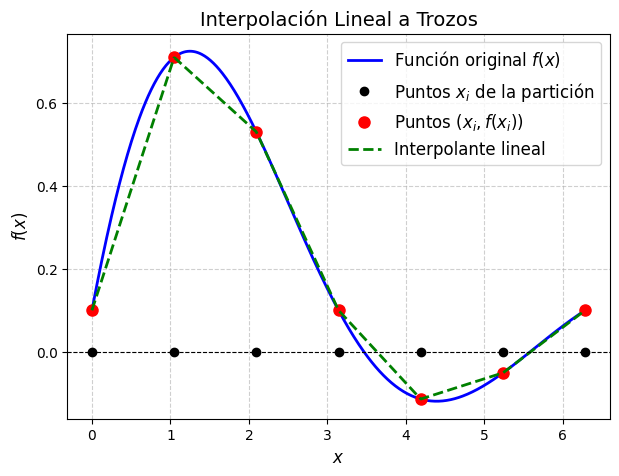

En el caso $n=3$ consideramos, en cada sub-intervalo, el polinomio de grado 2 que interpola en los extremos y en el punto medio de ese sub-intervalo.

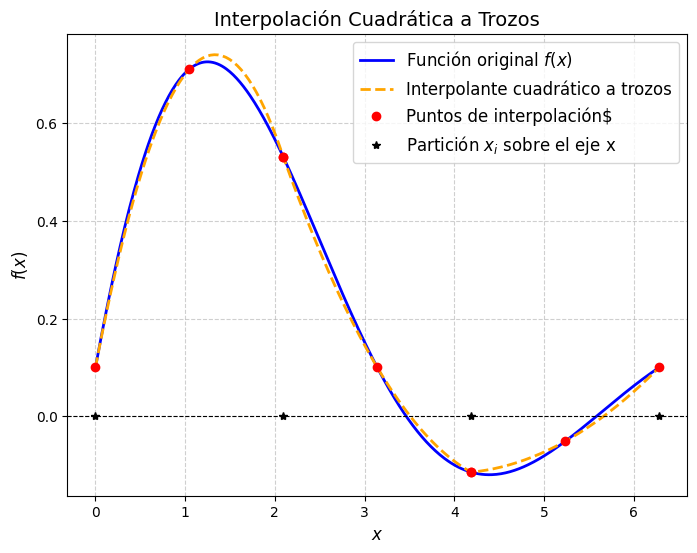

Así, se puede realizar para cualquier grado polinomial.

Luego, por el [teorema del error de interpolación](#teo:error.interp.polinomial), si fijamos $n$ (no demasiado grande) y miramos el error en un sub-intervalo, resulta que<br><br>

$$
|f(x) - p(x)| \le \frac{M_n}{n(n-1)^n}  \left(\frac{ |b-a|}L\right)^n.
$$<br>

Notemos que hemos cambiado $|b-a|$ por $\frac{|b-a|}L$, ya que estamos considerando un sub-intervalo, que tiene longitud $h = \frac{|b-a|}L$.

Resumimos esta observación en el siguiente teorema.

><font size = "5"> Teorema 2.8 </font> <a name="teo:error.interp.polinomial.a.trozos"></a>
>
> Sea $f$ es una función $C^n$ y $M_n$ es una cota para $|f^{(n)}|$
sobre el intervalo $[a,b]$.
Si $p$ es el polinomio a trozos de grado $\le n-1$ sobre una partición de tamaño $h = \frac{|b-a|}L$, que interpola a $f$ en $(L+1)+(n-2)L$ puntos equiespaciados, entonces<br><br>
$$
|f(x) - p(x)| \le \frac{M_n}{n(n-1)^n}  \left(\frac{ |b-a|}L\right)^n = \frac{M_n}{n(n-1)^n}  h^n,
$$<br>
para todo punto $x \in [a,b]$, con $M_n = \max_{\xi\in[a,b]} |f^n(\xi)|$.

Observemos que $n$ está fijo, y que podemos tomar $L$ grande. Si hacemos tender $L$ a infinito, resulta que<br><br>
$$
|f(x) - p(x)| \le \frac{M_n}{n(n-1)^n}  \left(\frac{ |b-a|}L\right)^n
 = \frac{M_n |b-a|^n}{n(n-1)^n}  \frac1{L^n} \to 0, \quad \text{cuando $L\to\infty$}.
$$<br>
Esto quiere decir que sin importar como se comporten las derivadas de nuestra función siempre que aumentemos la cantidad de subintervalos el error de interpolación a trozos tenderá a cero.

---
<font size="5">Pongámonos a prueba!!! 💪🏻</font> <br>

Intentá hallar la solución a los siguientes problemas con los conocimientos adquiridos en esta sección.
Recordá que si bien estás buscando un resultado en particular, herramientas como gráficas u otros cálculos auxiliares pueden ser de mucha ayuda para llegar a este.
Podés resolver utilizando celdas de código en este mismo Colab, o corriendo Python de manera local.

### Problema de interpolación polinomial a trozos 1

Dado el siguiente conjunto de puntos:

||||||||
|-|-|-|-|-|-|-|
|$x$|0|1|2|3|4|
|$y$|0|1|0.6|-0.2|-0.7|

1. Determina la cantidad de polinomios lineales a trozos que necesitamos para interpolar dichos puntos. Calcula los mismos.

2. Repite el ítem anterior pero con polinomios cuadráticos.

3. Realice un gráfico que ilustre las dos situaciones previas, es decir, donde figuren los puntos de la partición y los polinomios interpolantes a trozos calculados.

In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

### Problema de interpolación polinomial a trozos 2

Queremos aproximar la función $\sin(x)$ en el intervalo $[0,π]$ utilizando una partición con puntos equidistantes.

1. Obtenga una condición sobre la cantidad de elementos de la partición para que sea posible obtener una interpolación lineal a trozos. Repita lo mismo para interpolaciones cuadráticas y cúbicas a trozos.

2. Escoge un número de elementos para la partición que cumpla con las 3 condiciones obtenidas en el ítem anterior.

3. Realiza una interpolación lineal a trozos.

4. Realiza una interpolación cuadrática a trozos.

5. Realiza una interpolación cúbica a trozos.

6. Grafica la función $\sin(x)$ junto con las tres interpolaciones en el intervalo $[0,π]$.

7. Calcula y compara los errores de interpolación en el punto $x=\frac{π}{8}$ para cada método.

In [ ]:
# Usa esta celda sólo en caso de no disponer del Spyder en este momento

---
> <font size="5"> 👀 **Comentarios finales**</font>   
> 1. Existen diferentes estrategias para elegir los puntos de interpolación que también permiten hacer tender el error a cero sin requerir la interpolación a trozos. Por ejemplo, para funciones *absolutamente continuas* estos puntos son conocidos como *nodos de Chebyshev*.
> 2. También pueden agregarse condiciones de regularidad sobre cómo se *pegan* los trozos entre sí, dando lugar por ejemplo a los muy conocidos *splines cúbicos*, polinomios cúbicos que no sólo pasan por los puntos (interpolan) sino también que los trozos se pegan con igual derivada primera y segunda, dando como resultado una función $C^1$.
> 3. Y muuuuucho más ...

>>- **Polinomios de Lagrange**: no muy utilizados en la práctica, pero muy útiles en
contextos teóricos.

>>- **Polinomios de Hermite cúbicos**: similar a los splines cúbicos, pero además de los
valores de las funciones, también se toman en cuenta las derivadas en los puntos de
interpolación.

>> - **Polinomios de Bézier**: se utilizan principalmente en gráficos y diseño asistido por
computadora. Su forma se puede controlar mediante puntos de control.

>> - **Polinomios de B-Spline**: son una generalización de los splines cúbicos y se usan en modelado de estructuras con suvidades múltiples y en la resolución de ecuaciones
diferenciales.

---


 ## Ejercicios Adicionales ✍
Intentá hallar la solución a los siguientes problemas con los conocimientos adquiridos en este capítulo. Como verás, no hay un método único para resolver la mayoría de estos ejercicios.
Recordá que si bien estás buscando un resultado en particular, herramientas como gráficas u otros cálculos auxiliares pueden ser de mucha ayuda para llegar a este.
Podés resolver utilizando celdas de código en este mismo Colab, o corriendo Python de manera local.

### Ejercicio Adicional 1

Después de una tormenta, se mide la concentración de una determinada bacteria en un área de natación:

||||||||
|-|-|-|-|-|-|-|
|**t** ($\text{hs}$)|4|8|12|16|20|24|
|**c** ($\text{UFC/}100\text{mL}$)|1590|1320|1000|900|650|560|

El tiempo se mide en horas transcurridas despupes de finalizar la tormenta, y la unidad $\text{UFC}$ es una unidad de formación de colonia. Se sabe que un modelo para la concentración tiene la forma $c(t) = be^{-kt}$, donde $b$ y $k$ son constantes positivas.

1. Determine los valores de $b$ y de $k$, utilizando el método de mínimos cuadrados.

2. Utilice el modelo para estimar la concentración al final de la tormenta.

3. Utilice el modelo para determinar el tiempo en el que la concentración será 200 $\text{UFC/}100\text{mL}$.

In [ ]:
 # Usa esta celda sólo en caso de no disponer del Spyder en este momento

### Ejercicio Adicional 2

Con el fin de diseñar un proceso industrial en una planta productora de alimentos, un equipo de investigación realizó estudios de velocidad de una reacción enzimática. Para ello, colocó en un reactor una cierta cantidad de sustancia $S$ la cual, en presencia de una enzima, es transformada en productos de interés.

Se observa que la velocidad $r$ a la que se lleva a cabo esa transformación depende de la concentración $c_S$ a la cual se encuentra la sustancia en el reactor. Se realizaron distintas experiencias variando $c_S$ y midiendo $r$ en
cada caso.

Los resultados se muestran en la siguiente tabla, en la cual $r$ se mide en $\frac{\text{mmol}}{\text{L}\times\text{min}}$ y $c_S$ en $\frac{\text{mmol}}{\text{L}}$:



|$c_S$|1|2|3|5|7|10|15|20
|-|-|-|-|-|-|-|-|-|
|$r$|0.15|0.33|0.3|0.35|0.38|0.42|0.43|0.45|

Los investigadores pretenden describir la variación de $r$ respecto de $c_S$ utilizando el siguiente modelo, en el cual $r_m$ y $K_m$ son dos parámetros especpíficos del mismo:

$$
r = \frac{r_m c_S}{K_m + c_S}
$$

Con el objetivo de hallar los parámetros $r_m$ y $K_m$, se proponen dos linealizaciones de dicho modelo:


*   $\frac{1}{r}=\frac{1}{r_m}+ \frac{K_m}{c_S r_m}$, donde $\frac{1}{r}$ es una función lineal de $\frac{1}{c_S}$.

*   $r = r_m - K_m \frac{r}{c_S}$, donde $r$ es una función lineal de $\frac{r}{c_S}$.

En base a esto resuelva los siguientes ítems:

1. Para cada propuesta, calcule los valores de los parámetros utilizando un ajuste lineal por cuadrados mínimos y represente gráficamente la evolución de $r$ frente a $c_S$.

2. A través de una experiencia adicional se sabe que, a concentraciones elevadas de $S$, la velocidad de reacción $r$ es de aproximadamente $0.53 \frac{\text{mmol}}{\text{L}\times\text{min}}$ . En base a esta información, ¿qué valores de $r_m$ y $K_m$ considera más adecuados?

3. Con los valores de $r_m$ y $K_m$ elegidos en el inciso anterior, determine la ***concentración de saturación***, esto es, el valor de $c_S$ a partir del cual la velocidad de reacción $r$ prácticamente no varía. Para ello, considere
que esto ocurre cuando $\dfrac{dr}{dc_S}$ es igual a $0.001 \text{min}^{-1}$.


In [ ]:
 # Usa esta celda sólo en caso de no disponer del Spyder en este momento

### Ejercicio Adicional 3

Se ha registrado la velocidad (en $km/h$) de un objeto cada 12 minutos durante 5 horas. Los datos están guardados en el archivo `datos_velocidades.txt` (ver [Datos para el TP2](https://servicios.unl.edu.ar/aulavirtual/fiq/mod/folder/view.php?id=13093) en el aula virtual).

1. Determine la función de la forma $v(t) = c_1 \sin(2t) + c_2 t^2 + c_3 2^t + c_4$ que mejor aproxima a los datos en el sentido de cuadrados mínimos. (Escriba el valor de $c_1$, $c_2$, $c_3$ y $c_4$ con $4$ dígitos). Utilice el modelo para predecir el valor de la velocidad a las $6$ horas.

2. Hallar el polinomio $p_6$ de grado menor o igual que 6 que aproxima a los datos en el sentido de los cuadrados mínimos. Utilice este modelo para predecir el valor de la velocidad a las $6$ horas.

3. Calcule el error cuadrático de ambos ajustes. ¿Qué ajuste le parece más apropiado y por qué?

4. Utilice el modelo que le parezca más apropiado para calcular la distancia recorrida por el objeto durante las primeras $6$ horas.


In [ ]:
 # Usa esta celda sólo en caso de no disponer del Spyder en este momento

In [ ]:
import numpy as np

a = np.array([1,2,3])
b=a
a[0]=2
b